# Ejercicios Prácticos - Algoritmos básicos de clasificación

##### II DIPLOMA DE EXPERTO EN APRENDIZAJE AUTOMÁTICO AVANZADO EN PYTHON
#### Alumno: Pablo Fazio Arrabal

---

## Ejercicios Básicos

1. Modifique la gráfica que se muestra en el apartado “Base de datos Iris” de la práctica para que:

    - Las muestras de la variedad Setosa se representen mediante triángulos verdes.
    - Las muestras Versicolor se representen mediante cuadrados naranjas.
    - La leyenda se dibuje en la parte inferior derecha de la gráfica (*pista: lower right*).
    - Muestre la salida obtenida.

In [89]:
# Vamos a cargar en primer lugar la base de datos Iris

import os
import pandas as pd
s = os.path.join('https://archive.ics.uci.edu', 'ml','machine-learning-databases','iris','iris.data')
print('URL:', s)

# La guardamos en un dataframe llamado 'df'
df = pd.read_csv(s, header=None, encoding='utf-8')

# Visualizamos las primeras filas de la base de datos
df.head()

URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


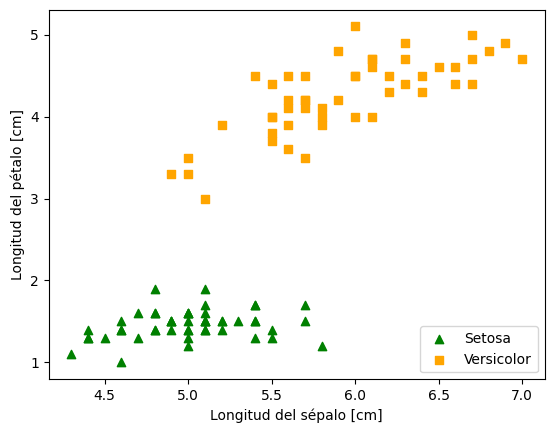

In [90]:
# Ahora, modificamos la gráfica de la práctica guiada para cumplir los requerimientos del ejercicio

import matplotlib.pyplot as plt
import numpy as np

# Mantenemos las clases 'setosa' y 'versicolor'
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1)
X = df.iloc[0:100, [0, 2]].values

# 1. Modificamos el color a 'green' y el marcador a '^' (triángulos)
plt.scatter(X[y[:]==-1,0], X[y[:]==-1,1], color='green', marker='^', label='Setosa')
# 2. Modificamos el color a 'orange' y el marcador a 's' (cuadrados)
plt.scatter(X[y[:]==1,0], X[y[:]==1,1], color='orange', marker='s', label='Versicolor')

plt.xlabel('Longitud del sépalo [cm]')
plt.ylabel('Longitud del pétalo [cm]')

# 3. Modificamos la ubicación de la leyenda a la esquina inferior derecha
plt.legend(loc='lower right')

# 4. Mostramos la salida obtenida
plt.show()

2. Imagine que quiere mostrar el detalle ampliado de las muestras que tienen una longitud del sépalo y una longitud del pétalo concretos, como el siguiente ejemplo:

    <div align="center">
        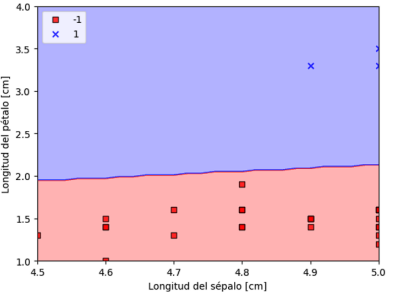
    </div>

    Cree una nueva función denominada *pintar_regiones_decision_zoom* basándose en la función *pintar_regiones_decision* para ampliar las muestras que tienen una longitud del sépalo de entre 5 y 6 centímetros y una longitud del pétalo de entre 1.5 y 4 centímetros.

    **a)** ¿Cuál sería su código?

    **b)** Copie una captura de la salida.


In [91]:
# APARTADO A)
from matplotlib.colors import ListedColormap

def pintar_regiones_decision_zoom(X, y, clasificador, resolucion=0.02):
    marcadores = ('s', 'x', 'o', '^', 'v')
    colores = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colores[:len(np.unique(y))])

    # Basta modificar los límites de xi_min y xi_max de forma que estén entre
    # 5 y 6 cm en el eje X y 1.5 y 4 cm en el eje Y. El resto de la función
    # se mantiene igual.

    x1_min, x1_max = 5, 6
    x2_min, x2_max = 1.5, 4

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolucion),
                           np.arange(x2_min, x2_max, resolucion))

    Z = clasificador.prediccion(np.array([xx1.reshape(-1), xx2.reshape(-1)]).T)
    Z = Z.reshape(xx1.shape)

    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
         plt.scatter(x=X[y == cl, 0],
                     y=X[y == cl, 1],
                     alpha=0.8,
                     c=colores[idx],
                     marker=marcadores[idx],
                     label=cl,
                     edgecolor='black')

**APARTADO B)**

Usando el mismo dataset que en la práctica, se nos mostrará el siguiente resultado:

<div align="center">
    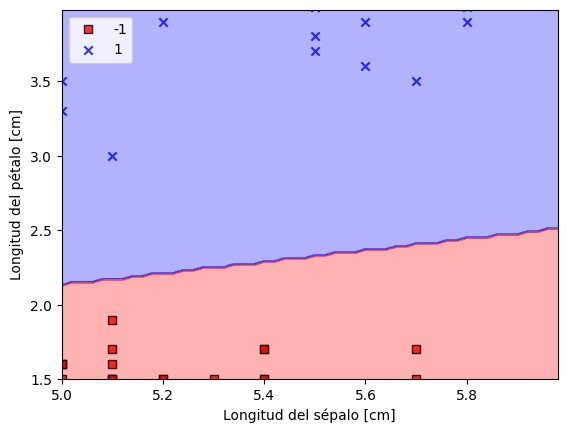
</div>

3.  Modifique el apartado “Adaline estocástica aplicada a Iris estandarizada” para entrenar una adaline estocástica con los siguientes parámetros:

      *i)* Tasa de aprendizaje: 0.0005

      *ii)* Épocas de entrenamiento: 5

    Use el mismo conjunto de entrenamiento, es decir, rasgos 0 y 2 estandarizados.

    **a)** Copie una captura de las dos gráficas resultantes: evolución del error cuadrático medio en función de la época y gráfica con superficie de decisión.

    **b)** ¿Ha resuelto el problema de clasificación correctamente considerando el signo de la salida? Razone su respuesta apoyándose en alguna de las gráficas del apartado anterior.

    **c)** En este problema de clasificación y considerando directamente la salida de una Adaline (NO su signo), ¿cree que es posible lograr un error cuadrático medio de cero? Razone su respuesta.

**APARTADO A)**

Los resultados que se nos muestran son los siguientes:

<div align = "center">
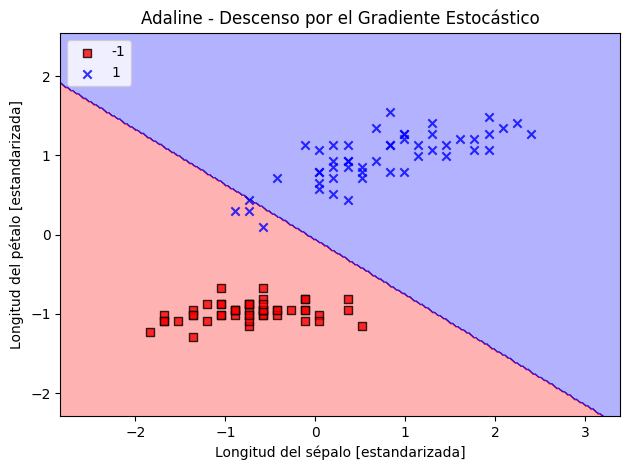

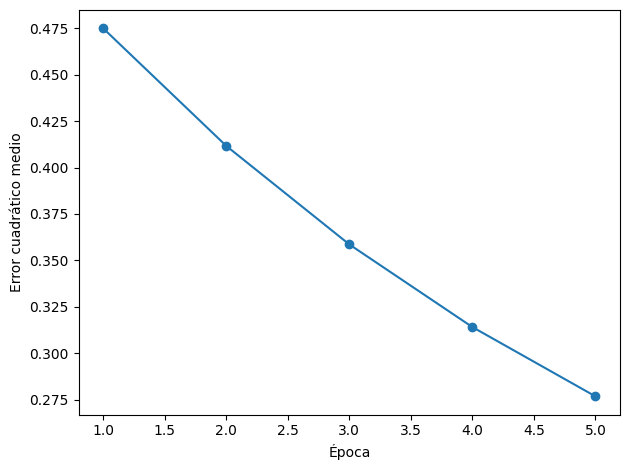
</div>

**APARTADO B)**

**No.** Como vemos en la primera gráfica (gráfica de superficie de decisión), existen variantes de Versicolor que se incluyen en la zona que las clasifica como Setosa. Considero que hemos definido una tasa de aprendizaje <u>demasiado pequeña</u> y muy pocas épocas de aprendizaje para que se puedan clasificar correctamente.

**APARTADO C)**

**No**, no es posible lograr un error cuadrático medio nulo. Esto sucede ya que vimos que Adalina usa una función de activación lineal, es decir, $\phi(h) = h$.

El algoritmo trata de minimizar la diferencia entre el valor real ($1$ ó $-1$) de la clase y la salida continua de la red (número real). Para que el error fuera exactamente $0$, la salida de la función tendría que ser exactamente $-1$ para todas las muestras de una clase y exactamente $1$ para todas las muestras de la otra, algo bastante improbable.

4. Dibuje en una gráfica <u>todas las muestras</u> que hay en la base de datos Iris atendiendo al rasgo 0 y 2. Dibuje cada una de las <u>tres clases</u> con un marcador diferente.

    **a)** Copie el código que ha usado y explique la modificación que ha realizado.

    **b)** Copie una captura de la gráfica.

    **c)** ¿Qué modelo o técnica utilizaría para clasificar estas muestras? Razone su respuesta.

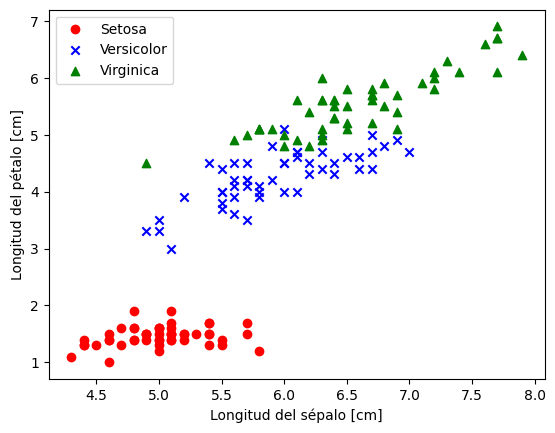

In [92]:
# APARTADO A) y APARTADO B)

# Elegir setosa, veriscolor y virginica (Usaremos las etiquetas que aparecen)
y = df.iloc[:, 4].values

# Extraer los atributos de la longitud del sépalo y del pétalo
X = df.iloc[:, [0, 2]].values

# Dibujar los datos
# Dibujar las muestras tipo Setosa
plt.scatter(X[y[:]=="Iris-setosa",0], X[y[:]=="Iris-setosa",1], color='red', marker='o', label='Setosa')
# Dibujar las muestras tipo Versicolor
plt.scatter(X[y[:]=="Iris-versicolor",0], X[y[:]=="Iris-versicolor",1], color='blue', marker='x', label='Versicolor')
# Dibujar las muestras tipo Virginica
plt.scatter(X[y[:]=="Iris-virginica",0], X[y[:]=="Iris-virginica",1], color = 'green', marker = '^', label= 'Virginica')

# Dibujar leyenda y etiquetar los ejes
plt.xlabel('Longitud del sépalo [cm]')
plt.ylabel('Longitud del pétalo [cm]')
plt.legend(loc='upper left')
plt.show()

**APARTADO C)**

Este modelo se puede clasificar usando la estrategia **One vs All (OvA)**. Como queremos clasificar más de dos clases, podemos diseñar varios clasificadores que detecten cada una de las tres clases por separado.

El problema es que, además, como vemos en la gráfica, Virginica y Versicolor <u>no son linealmente separables</u> por lo que necesitamos un clasificador no lineal.

---

Para el resto de ejercicios que nos quedan, vamos a escribir la definición de las clases Adeline y Adeline Estocástico que usaremos en muchos de ellos.

In [93]:
# DEFINICIÓN CLASE ADALINE

class AdalineDG(object):
    """ADAptive LInear NEuron con Descenso por el Gradiente por lotes.

    Parámetros
    ----------
    eta : float
        Tasa de aprendizaje (entre 0.0 y 1.0)
    n_epoc : int
        Cantidad de épocas de entrenamiento
    estado_aleatorio : int
      Semilla generadora de número aleatorios para la inicialización de pesos
      aleatorios

    Atributos
    ---------
    w_ : 1d-array
        Pesos sinápticos de la red.
    coste_ : list
        Suma de errores cuadráticos en cada época calculados con la función
        de coste.

    """
    def __init__(self, eta=0.01, n_epoc=50, estado_aleatorio=1):
        self.eta = eta
        self.n_epoc = n_epoc
        self.estado_aleatorio = estado_aleatorio

    def entrenar(self, X, y):
        """ Entrenar con muestras de entrenamiento.

        Parámetros
        ----------
        X : {array-like}, shape = [n_ejemplos, n_rasgos]
            Vectores de entrenamiento, donde n_ejemplos
            es el número de muestras y
            n_rasgos es el número de rasgos/atributos.
        y : array-like, shape = [n_ejemplos]
            Valores objetivos/deseados.

        Devuelve
        --------
        self : objecto

        """
        rgen = np.random.RandomState(self.estado_aleatorio)
        self.w_ = rgen.normal(loc=0.0, scale=0.01,
                              size=1 + X.shape[1])
        self.coste_ = []

        for i in range(self.n_epoc):
            # Cálculo de potenciales para las muestras del lote
            pot= self.potencial(X)
            # Cálculo de las salidas para el lote
            salidas = self.activacion(pot)
            # Cálculo de errores
            errores = (y - salidas)
            # Ajuste de cada peso
            self.w_[0] += self.eta * errores.sum()
            self.w_[1:] += self.eta * X.T.dot(errores)
            # Anotación del coste o error en esta i-ésima época
            coste_epoca = (errores**2).sum() / 2.0
            self.coste_.append(coste_epoca)
        return self

    def potencial(self, X):
        """Calcular el potencial sináptico para las muestras de un lote"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activacion(self, Pot):
        """Calcula la función de activación/transferencia"""
        return Pot

    def prediccion(self, X):
        """Devuelve la etiqueta de clase para cada muestra"""
        return np.where(self.activacion(self.potencial(X))
                        >= 0.0, 1, -1)

In [94]:
# DEFINICIÓN CLASE ADELINE ESTOCÁSTICO

class AdalineDGS(object):
    """ADAptive LInear NEuron con Descenso por el Gradiente eStocástico.

    Parámetros
    ------------
    eta : float
        Tasa de aprendizaje (entre 0.0 y 1.0)
    n_epoc : int
        Cantidad de épocas de entrenamiento
    barajar : bool (por defecto: True)
        Si True, baraja las muestras de entrenamiento en cada época para
        evitar ciclos.
    random_state : int
        Semilla generadora de número aleatorios para la inicialización de los
        pesos aleatorios.


    Atributos
    -----------
    w_ : 1d-array
        Pesos sinápticos de la neurona.
    coste_ : list
        Error cuadrático medio en las muestras de entrenamiento
        en cada época.


    """
    def __init__(self, eta=0.01, n_epoc=10,
              barajar=True, estado_aleatorio=None):
        self.eta = eta
        self.n_epoc = n_epoc
        self.w_inicializados = False
        self.barajar = barajar
        self.estado_aleatorio = estado_aleatorio

    def entrenar(self, X, y):
        """ Entrena la neurona con las muestras de entrenamiento

        Parámetros
        ----------
        X : {array-like}, shape = [n_examples, n_features]
            Vectores de entrenamiento, donde n_examples
            es el número de muestras y n_features es el número de
            rasgos/atributos.
        y : array-like, shape = [n_examples]
            Valores objetivos/deseados.

        Devuelve
        -------
        self : objecto

        """
        self._inicializar_pesos(X.shape[1])
        self.coste_ = []
        for i in range(self.n_epoc):
            if self.barajar:
                X, y = self._barajar(X, y)
            coste_epoca = []
            for xi, objetivo in zip(X, y):
                coste_epoca.append(self._actualizar_pesos(xi, objetivo))
            coste_medio = sum(coste_epoca) / len(y)
            self.coste_.append(coste_medio)
        return self

    def entrenar_parcial(self, X, y):
        """Entrena con la muestras sin reiniciar los pesos cada vez"""
        if not self.w_inicializados:
            self._inicializar_pesos(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, objetivo in zip(X, y):
                self._actualizar_pesos(xi, objetivo)
        else:
            self._actualizar_pesos(X, y)
        return self

    def _barajar(self, X, y):
        """Baraja los datos de entrenamiento"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]

    def _inicializar_pesos(self, n_rasgos):
        """Inicializa los pesos con números aleatorios pequeños"""
        self.rgen = np.random.RandomState(self.estado_aleatorio)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01,
                                   size=1 + n_rasgos)
        self.w_inicializados = True

    def _actualizar_pesos(self, xi, objetivo):
        """Aplica la regla de aprendizaje de la Adaline para actualizar
        los pesos"""
        salida = self.activacion(self.potencial(xi))
        error = (objetivo - salida)
        self.w_[0] += self.eta * error
        self.w_[1:] += self.eta * xi.dot(error)
        coste = 0.5 * error**2
        return coste

    def potencial(self, X):
        """Calcula el potencial sináptico"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activacion(self, Pot):
        """Calcula la función de activación/transferencia
        (lineal en este caso)"""
        return Pot

    def prediccion(self, X):
        """Devuelve la etiqueta de clase para cada muestra"""
        return np.where(self.activacion(self.potencial(X))
                        >= 0.0, 1, -1)

5. Cargue el fichero glass.csv en su Google Colab. A continuación lea el fichero y guarde su contenido en una variable. Si quiere, puede usar el siguiente código:


    ```
    df5 = pd.read_csv('glass.csv', names=['ID','RI','Na','Mg','Al','Si','K','Ca','Ba','Fe','ClaseCristal'])
    ```

  - La clase deseada es ClaseCristal y hay siete clases de cristales, realiza la siguiente transformación:
      * Los valores 1, 2, 3 y 4 (cristales de ventana) serán la clase negativa.
      * Los valores 5, 6 y 7 (cristales no de ventana) serán la clase positiva.
  - Seleccione y estandarice los siguientes rasgos:
      * Sodio (Na)
      * Aluminio (Al)
  - Clasifique estos datos mediante una Adaline estocástica con 20 épocas de entrenamiento, una tasa de aprendizaje constante de 0.005 y un estado aleatorio inicial de 1.

    **a)** Dibuje el estado final de las regiones de decisión y la evolución del error cuadrático medio a lo largo de las épocas.

    **b)** ¿Clasifica bien todas las muestras? ¿en qué clase comete más fallos? Razone sus respuestas haciendo referencia a alguna gráfica del apartado anterior.



In [95]:
import pandas as pd

# En primer lugar, cargamos el archivo glass.csv en un dataframe con pandas

df5 = pd.read_csv('glass.csv', names=['ID','RI','Na','Mg','Al','Si','K','Ca',
'Ba','Fe','ClaseCristal'])

# Hacemos la transformación de la clase objetivo (valores 1-4 con clase -1 y resto con clase 1)
y = df5['ClaseCristal'].values
y = np.where(y <= 4, -1, 1)

# Selección de rasgos: Sodio (Na) y Aluminio (Al)
X = df5[['Na', 'Al']].values

# Estandarización de las muestras
X_std = np.copy(X)
X_std[:,0] = (X[:,0] - X[:,0].mean()) / X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()

# Cargamos un objeto Adalina estocástisco con los parámetros requeridos
ada_dgs = AdalineDGS(n_epoc=20, eta=0.005, estado_aleatorio=1)
ada_dgs.entrenar(X_std,y)

/tmp/ipython-input-2512747513.py:33: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


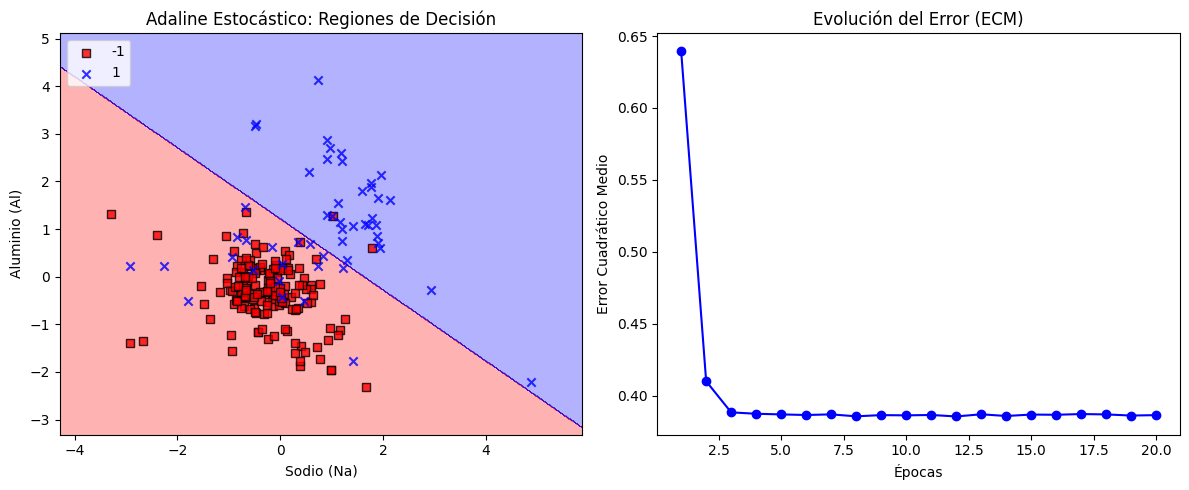

In [96]:
# APARTADO A)

def pintar_regiones_decision(X, y, clasificador, resolucion=0.02):
    # Configurar los marcadores y el mapa de color
    marcadores = ('s', 'x', 'o', '^', 'v')
    colores = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    # Asignación de colores a las clases
    cmap = ListedColormap(colores[:len(np.unique(y))])

    # Preparar los márgenes de la superficie de decisión
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Preparar los valores puntuales de la superficie de decisión y el valor del
    # clasifidor para dichos puntos
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolucion),
                           np.arange(x2_min, x2_max, resolucion))

    # Pasamos la entrada a matriz con dos columnas para calcular la salida del
    # clasificador
    Z = clasificador.prediccion(np.array([xx1.reshape(-1), xx2.reshape(-1)]).T)
    # Convertimos la salida predicha al formato adecuado para pintar la
    # superficie
    Z = Z.reshape(xx1.shape)

    # Pintar el contorno de la superficie de decisión y se rellena también
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Pintar las muestras en la superficie de decisión
    for idx, cl in enumerate(np.unique(y)):
         plt.scatter(x=X[y == cl, 0],
                     y=X[y == cl, 1],
                     alpha=0.8,
                     c=colores[idx],
                     marker=marcadores[idx],
                     label=cl,
                     edgecolor='black')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico 1: Regiones de Decisión ---
plt.sca(ax[0])
pintar_regiones_decision(X_std, y, clasificador=ada_dgs)
ax[0].set_title('Adaline Estocástico: Regiones de Decisión')
ax[0].set_xlabel('Sodio (Na)')
ax[0].set_ylabel('Aluminio (Al)')
ax[0].legend(loc='upper left')

# --- Gráfico 2: Evolución del ECM ---
ecm_historico = [c * 2.0 for c in ada_dgs.coste_]
ax[1].plot(range(1, len(ecm_historico) + 1), ecm_historico, marker='o', color='blue')
ax[1].set_title('Evolución del Error (ECM)')
ax[1].set_xlabel('Épocas')
ax[1].set_ylabel('Error Cuadrático Medio')

plt.tight_layout()
plt.show()

**APARTADO B)**

**No clasifica correctamente** la muestras según el primer gráfico. Al ser un clasificador lineal solo podemos trazar una recta de separación de los datos para las zonas de decisión y no es posible separar ambas clases.

Comete más fallos en la Clase Positiva (**Cristales No de Ventana**). Esto se debe a que la clase negativa tiene muchos más valores y ocupa una región central densa que se mezclan con otros de la clase positiva, como vemos en la primera gráfica.


## Ejercicio Avanzado

6.  Comparar el error cuadrático medio del Adaline frente al Adaline estocástico en la base de datos Iris, para valores de la tasa de aprendizaje comprendidos entre 0.001 y 0.01, en incrementos de 0.001. Sea *p* la cantidad de patrones, el Error Cuadrático Medio se define como:

$$ECM = \frac{1}{p} \sum_{i=1}^{p} (\hat{y}^{(i)} - h^{(i)})^2$$


  - Los rasgos serán la longitud del sépalo y la del pétalo estandarizados.
  - Las clases deseadas serán Setosa y Versicolor.
  - El número de épocas será 20 en todos los casos.
  - El error mostrado será el obtenido después de las 20 épocas de entrenamiento.
  - Muestre los resultados en una sola gráfica con dos curvas, los resultados del Adaline se verán en verde, y los del Adaline estocástico en azul.
  - El eje horizontal representará los diferentes valores de la tasa de aprendizaje.
  - El eje vertical (el de los errores) debe tener escala logarítmica para apreciar mejor las diferencias.

In [97]:
# Seleccionamos del dataframe las clases Setosa y Versicolor
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1)

# Seleccionamos en el dataframe los rasgos longitud de sépalo ('0') y longitud de pétalo ('2')
X = df.iloc[0:100, [0, 2]].values

# Estandarizamos la muestra
X_std = np.copy(X)
X_std[:,0] = (X[:,0] - X[:,0].mean()) / X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()

# Establecemos el número de epocas para todas las iteraciones
num_epocs_fix = 20

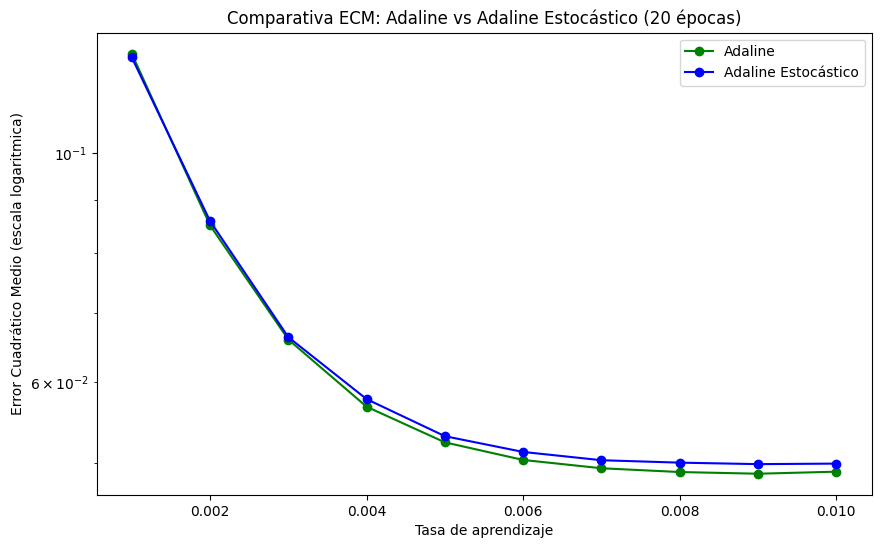

In [98]:
# Guardaremos los ECM por tasa de aprendizaje de ambos clasificadores
tasas_aprendizaje = np.arange(0.001, 0.011, 0.001)
ecm_adaline = []
ecm_estocastico = []

# Iteramos según la tasa de aprendizaje eta desde 0.001 hasta 0.01 con paso 0.001
for eta_iter in tasas_aprendizaje:
  # Inicializamos un objeto Adaline con 20 épocas y la tasa de aprendizaje correspondiente
  ada = AdalineDG(n_epoc=num_epocs_fix, eta=eta_iter)
  ada.entrenar(X_std, y)

  # Calculamos el error cuadrático medio para esa iteración y
  # lo añadimos a la lista de errores
  p = len(y)
  ecm_final_ada = (ada.coste_[-1] * 2.0) / p
  ecm_adaline.append(ecm_final_ada)

  # Inicializamos un objeto Adaline Estocástico con 20 épocas y la tasa de aprendizaje correspondiente
  ada_dgs = AdalineDGS(n_epoc=num_epocs_fix, eta=eta_iter)
  ada_dgs.entrenar(X_std,y)
  ecm_final_dgs = ada_dgs.coste_[-1] * 2.0
  ecm_estocastico.append(ecm_final_dgs)

plt.figure(figsize=(10, 6))

# Dibujamos las curvas con el formato requerido
plt.plot(tasas_aprendizaje, ecm_adaline,
         color='green', marker='o', label='Adaline')
plt.plot(tasas_aprendizaje, ecm_estocastico,
         color='blue', marker='o', label='Adaline Estocástico')

plt.xlabel('Tasa de aprendizaje')
plt.ylabel('Error Cuadrático Medio (escala logaritmica)')
plt.title('Comparativa ECM: Adaline vs Adaline Estocástico (20 épocas)')
# Para que el eje vertical tenga escala logarítmica se debe fijar de esta forma
plt.yscale('log')
plt.legend(loc='upper right')

plt.show()

## Ejercicio Experto

7. Implementar el Adaline y el Adaline estocástico con tasas de aprendizaje decrecientes. La tasa de aprendizaje en cada época i vendrá dada por:

$$ tasa(i) = eta * exp(-i/n\_epoc) $$

- Comparar con las versiones estándar de ambos modelos, repitiendo los
experimentos del ejercicio de nivel avanzado. Pruebe valores de la tasa de aprendizaje comprendidos entre 0.001 y 0.02, en incrementos de 0.001.
- Use los mismos rasgos y clases que en el ejercicio avanzado. Dibuje una gráfica con dos curvas.
- Explique los resultados obtenidos.

*Pista: podría crear dos nuevas subclases redefiniendo únicamente aquellos métodos que crea necesarios.*


In [99]:
# DEFINICIÓN CLASE ADALINE CON TASA DECRECIENTE

class AdalineDG_TDec(object):
    """ADAptive LInear NEuron con Descenso por el Gradiente por lotes con tasa de aprendizaje decreciente

    Parámetros
    ----------
    eta : float
        Tasa de aprendizaje (entre 0.0 y 1.0)
    n_epoc : int
        Cantidad de épocas de entrenamiento
    estado_aleatorio : int
      Semilla generadora de número aleatorios para la inicialización de pesos
      aleatorios

    Atributos
    ---------
    w_ : 1d-array
        Pesos sinápticos de la red.
    coste_ : list
        Suma de errores cuadráticos en cada época calculados con la función
        de coste.

    """
    def __init__(self, eta=0.01, n_epoc=50, estado_aleatorio=1):
        self.eta = eta
        self.n_epoc = n_epoc
        self.estado_aleatorio = estado_aleatorio

    def entrenar(self, X, y):
        """ Entrenar con muestras de entrenamiento.

        Parámetros
        ----------
        X : {array-like}, shape = [n_ejemplos, n_rasgos]
            Vectores de entrenamiento, donde n_ejemplos
            es el número de muestras y
            n_rasgos es el número de rasgos/atributos.
        y : array-like, shape = [n_ejemplos]
            Valores objetivos/deseados.

        Devuelve
        --------
        self : objecto

        """
        rgen = np.random.RandomState(self.estado_aleatorio)
        self.w_ = rgen.normal(loc=0.0, scale=0.01,
                              size=1 + X.shape[1])
        self.coste_ = []

        for i in range(self.n_epoc):
            # Cálculo de potenciales para las muestras del lote
            pot= self.potencial(X)
            # Cálculo de las salidas para el lote
            salidas = self.activacion(pot)
            # Cálculo de errores
            errores = (y - salidas)
            # Ajuste de cada peso
            # modifica self.eta por self.tasa_decreciente(i)
            self.w_[0] += self.tasa_decreciente(i) * errores.sum()
            self.w_[1:] += self.tasa_decreciente(i) * X.T.dot(errores)
            # Anotación del coste o error en esta i-ésima época
            coste_epoca = (errores**2).sum() / 2.0
            self.coste_.append(coste_epoca)
        return self

    def potencial(self, X):
        """Calcular el potencial sináptico para las muestras de un lote"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activacion(self, Pot):
        """Calcula la función de activación/transferencia"""
        return Pot

    def prediccion(self, X):
        """Devuelve la etiqueta de clase para cada muestra"""
        return np.where(self.activacion(self.potencial(X))
                        >= 0.0, 1, -1)

    # Defino un nuevo método que calcule la tasa de aprendizaje en función del
    # número de epoca en el que me encuentre (seguimos la fórmula enunciada)
    def tasa_decreciente(self, num_epoc):
        """Devuelve la tasa de aprendizaje en la epoca concreta"""
        return self.eta*np.exp(-num_epoc/self.n_epoc)


In [100]:
# DEFINICIÓN CLASE ADALINE ESTOCÁSTISCA CON TASA DECRECIENTE

class AdalineDGS_TDec(object):
    """ADAptive LInear NEuron con Descenso por el Gradiente eStocástico con tasa de aprendizaje decreciente.

    Parámetros
    ------------
    eta : float
        Tasa de aprendizaje (entre 0.0 y 1.0)
    n_epoc : int
        Cantidad de épocas de entrenamiento
    barajar : bool (por defecto: True)
        Si True, baraja las muestras de entrenamiento en cada época para
        evitar ciclos.
    random_state : int
        Semilla generadora de número aleatorios para la inicialización de los
        pesos aleatorios.


    Atributos
    -----------
    w_ : 1d-array
        Pesos sinápticos de la neurona.
    coste_ : list
        Error cuadrático medio en las muestras de entrenamiento
        en cada época.


    """
    def __init__(self, eta=0.01, n_epoc=10,
              barajar=True, estado_aleatorio=None):
        self.eta = eta
        self.n_epoc = n_epoc
        self.w_inicializados = False
        self.barajar = barajar
        self.estado_aleatorio = estado_aleatorio

    def entrenar(self, X, y):
        """ Entrena la neurona con las muestras de entrenamiento

        Parámetros
        ----------
        X : {array-like}, shape = [n_examples, n_features]
            Vectores de entrenamiento, donde n_examples
            es el número de muestras y n_features es el número de
            rasgos/atributos.
        y : array-like, shape = [n_examples]
            Valores objetivos/deseados.

        Devuelve
        -------
        self : objecto

        """
        self._inicializar_pesos(X.shape[1])
        self.coste_ = []
        for i in range(self.n_epoc):
            if self.barajar:
                X, y = self._barajar(X, y)
            coste_epoca = []
            for xi, objetivo in zip(X, y):
                coste_epoca.append(self._actualizar_pesos(xi, objetivo, i))
            coste_medio = sum(coste_epoca) / len(y)
            self.coste_.append(coste_medio)
        return self

    def _barajar(self, X, y):
        """Baraja los datos de entrenamiento"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]

    def _inicializar_pesos(self, n_rasgos):
        """Inicializa los pesos con números aleatorios pequeños"""
        self.rgen = np.random.RandomState(self.estado_aleatorio)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01,
                                   size=1 + n_rasgos)
        self.w_inicializados = True

    def _actualizar_pesos(self, xi, objetivo, epoca):
        """Aplica la regla de aprendizaje de la Adaline para actualizar
        los pesos"""
        # Calculamos la tasa de aprendizaje en función de la época i
        eta_i = self.eta * np.exp(-epoca / self.n_epoc)
        salida = self.activacion(self.potencial(xi))
        error = (objetivo - salida)
        self.w_[0] += eta_i * error
        self.w_[1:] += eta_i * xi.dot(error)
        coste = 0.5 * error**2
        return coste

    def potencial(self, X):
        """Calcula el potencial sináptico"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activacion(self, Pot):
        """Calcula la función de activación/transferencia
        (lineal en este caso)"""
        return Pot

    def prediccion(self, X):
        """Devuelve la etiqueta de clase para cada muestra"""
        return np.where(self.activacion(self.potencial(X))
                        >= 0.0, 1, -1)

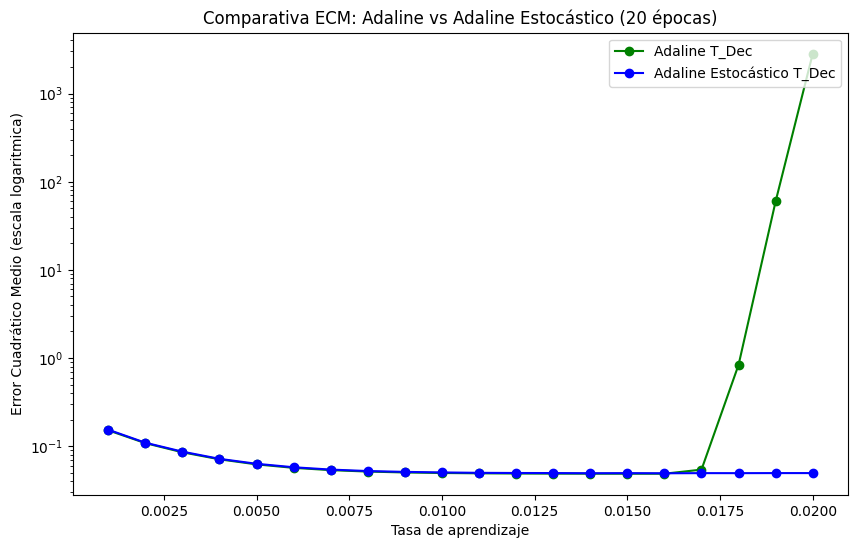

In [101]:
# Guardaremos los ECM por tasa de aprendizaje de ambos clasificadores
tasas_aprendizaje = np.arange(0.001, 0.021, 0.001)
ecm_adaline = []
ecm_estocastico = []

# Asumo que también usaremos el 'num_epocs_fix'

# Iteramos según la tasa de aprendizaje eta desde 0.001 hasta 0.01 con paso 0.001
for eta_iter in tasas_aprendizaje:
  # Inicializamos un objeto Adaline con 20 épocas y la tasa de aprendizaje correspondiente
  ada = AdalineDG_TDec(n_epoc=num_epocs_fix, eta=eta_iter)
  ada.entrenar(X_std, y)

  # Calculamos el error cuadrático medio para esa iteración y
  # lo añadimos a la lista de errores
  p = len(y)
  ecm_final_ada = (ada.coste_[-1] * 2.0) / p
  ecm_adaline.append(ecm_final_ada)

  # Inicializamos un objeto Adaline Estocástico con 20 épocas y la tasa de aprendizaje correspondiente
  ada_dgs = AdalineDGS_TDec(n_epoc=num_epocs_fix, eta=eta_iter)
  ada_dgs.entrenar(X_std,y)
  ecm_final_dgs = ada_dgs.coste_[-1] * 2.0
  ecm_estocastico.append(ecm_final_dgs)

plt.figure(figsize=(10, 6))

# Dibujamos las curvas con el formato requerido
plt.plot(tasas_aprendizaje, ecm_adaline,
         color='green', marker='o', label='Adaline T_Dec')
plt.plot(tasas_aprendizaje, ecm_estocastico,
         color='blue', marker='o', label='Adaline Estocástico T_Dec')

plt.xlabel('Tasa de aprendizaje')
plt.ylabel('Error Cuadrático Medio (escala logaritmica)')
plt.title('Comparativa ECM: Adaline vs Adaline Estocástico (20 épocas)')
# Para que el eje vertical tenga escala logarítmica se debe fijar de esta forma
plt.yscale('log')
plt.legend(loc='upper right')

plt.show()

Básicamente lo que nos encontramos es que aparece un <u>aumento exponencial del error en el Adaline normal</u> cuando la tasa de aprendizaje es alta.

Incluso con una tasa decreciente, el Adaline es muy sensible a la magnitud del gradiente. Cuando el $eta$ inicial es alto, los primeros ajustes de los pesos son tan grandes que el algoritmo cae fuera de su mínimo global.